In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('PWR','GS'), 
         ('PWR','CAT'), 
         ('PWR','MSFT'), 
         ('BK','GS'), 
         ('BK', 'CAT'),
         ('BK', 'MSFT'), 
         ('CMI','GS'), 
         ('CMI', 'CAT'), 
         ('CMI','MSFT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

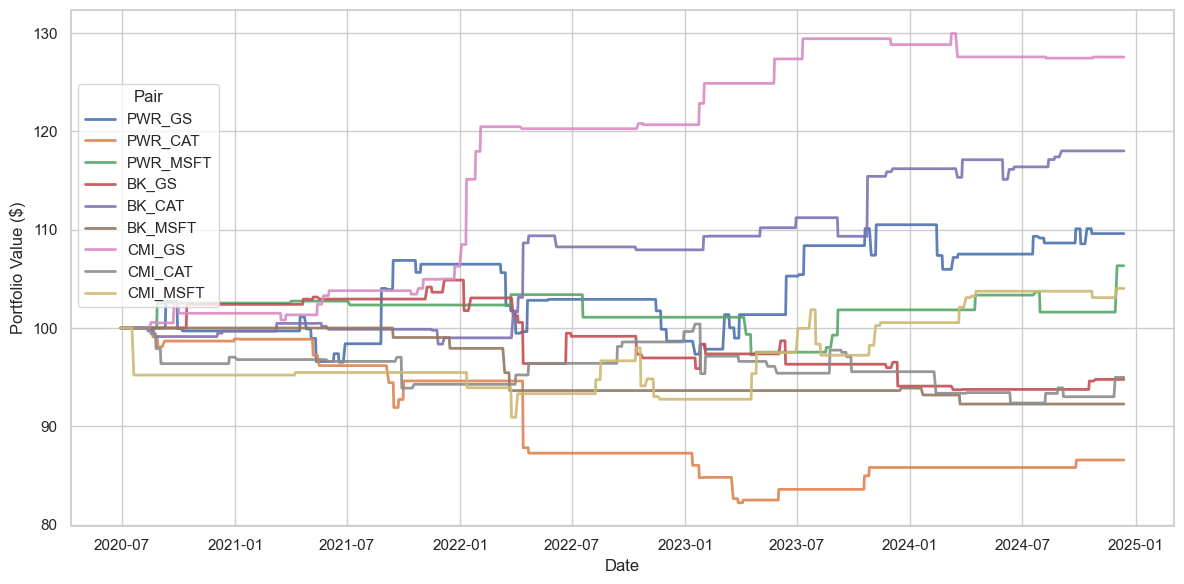

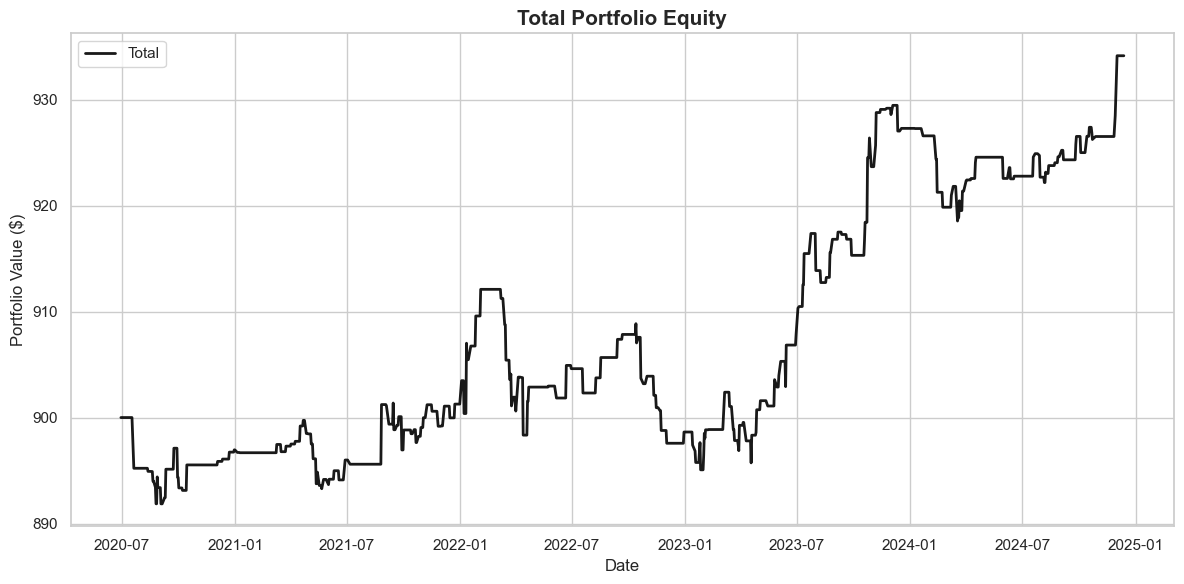

Summary
PWR_GS: Final Value = $109.61, Total Return = 9.61%, Trades = 49
PWR_CAT: Final Value = $86.57, Total Return = -13.43%, Trades = 23
PWR_MSFT: Final Value = $106.33, Total Return = 6.33%, Trades = 15
BK_GS: Final Value = $94.77, Total Return = -5.23%, Trades = 29
BK_CAT: Final Value = $118.02, Total Return = 18.02%, Trades = 34
BK_MSFT: Final Value = $92.26, Total Return = -7.74%, Trades = 8
CMI_GS: Final Value = $127.57, Total Return = 27.57%, Trades = 30
CMI_CAT: Final Value = $94.98, Total Return = -5.02%, Trades = 31
CMI_MSFT: Final Value = $104.03, Total Return = 4.03%, Trades = 27

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $934.15
Total Return:            3.79%

Sharpe Ratios
PWR_GS: Sharpe Ratio = 0.35
PWR_CAT: Sharpe Ratio = -0.69
PWR_MSFT: Sharpe Ratio = 0.41
BK_GS: Sharpe Ratio = -0.27
BK_CAT: Sharpe Ratio = 0.86
BK_MSFT: Sharpe Ratio = -1.02
CMI_GS: Sharpe Ratio = 1.31
CMI_CAT: Sharpe Ratio = -0.26
CMI_MSFT: Sharpe Ratio = 0

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)